In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    r"..\data\processed\utci_analysis.csv"
)

df["time"] = pd.to_datetime(df["time"])

# ---------------------------------------------------------
# Collapse the 3x3 ERA5 grid to one Ahmedabad-wide UTCI
# value for each hourly timestamp.
# ---------------------------------------------------------
df = (
    df.groupby("time", as_index=False)
      .agg(utci=("utci", "mean"))
)

print("Hourly Ahmedabad-wide UTCI:")
print(df.head())
print("\nShape:", df.shape)

Hourly Ahmedabad-wide UTCI:
                 time       utci
0 2021-04-01 00:00:00  17.888024
1 2021-04-01 01:00:00  17.238865
2 2021-04-01 02:00:00  20.237264
3 2021-04-01 03:00:00  25.875859
4 2021-04-01 04:00:00  29.658501

Shape: (13104, 2)


In [2]:
# ERA5 time is UTC → converting to Ahmedabad/India time
df["local_time"] = (
    df["time"]
    .dt.tz_localize("UTC")
    .dt.tz_convert("Asia/Kolkata")
)

df["local_time"] = df["local_time"].dt.tz_localize(None)

print(df[["time", "local_time"]].head(10))

                 time          local_time
0 2021-04-01 00:00:00 2021-04-01 05:30:00
1 2021-04-01 01:00:00 2021-04-01 06:30:00
2 2021-04-01 02:00:00 2021-04-01 07:30:00
3 2021-04-01 03:00:00 2021-04-01 08:30:00
4 2021-04-01 04:00:00 2021-04-01 09:30:00
5 2021-04-01 05:00:00 2021-04-01 10:30:00
6 2021-04-01 06:00:00 2021-04-01 11:30:00
7 2021-04-01 07:00:00 2021-04-01 12:30:00
8 2021-04-01 08:00:00 2021-04-01 13:30:00
9 2021-04-01 09:00:00 2021-04-01 14:30:00


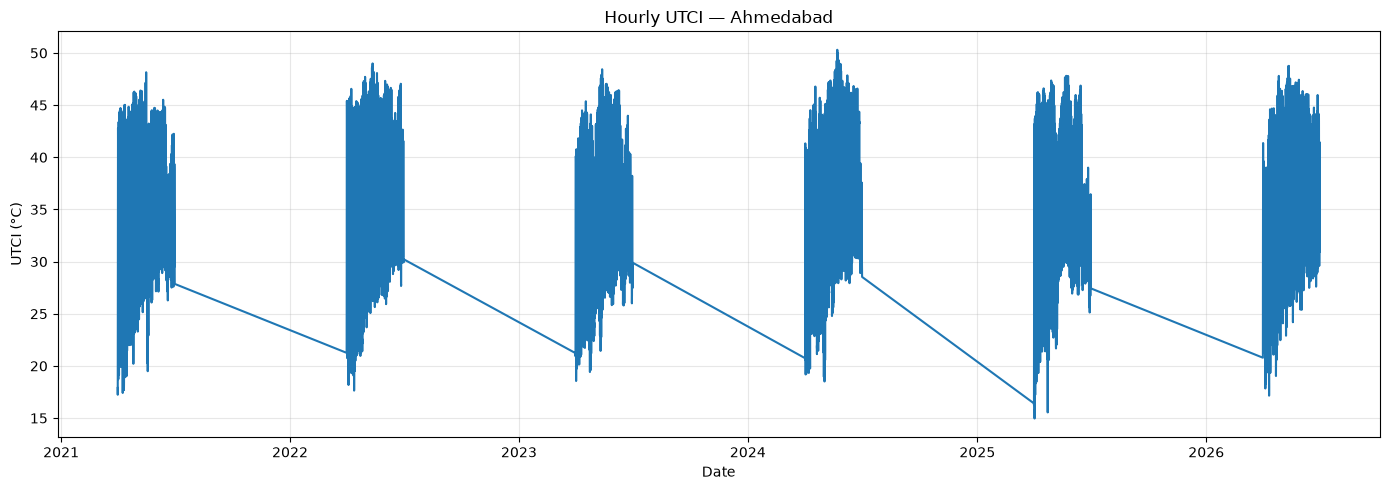

In [3]:
# GRAPH 1 — HOURLY UTCI

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    df["local_time"],
    df["utci"]
)

plt.xlabel("Date")
plt.ylabel("UTCI (°C)")
plt.title("Hourly UTCI — Ahmedabad")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
df["hour"] = df["local_time"].dt.hour

df["period"] = np.where(
    (df["hour"] >= 8) & (df["hour"] < 20),
    "day",
    "night"
)

print(df[["local_time", "hour", "period"]].head(20))

print("\nPeriod counts:")
print(df["period"].value_counts())

            local_time  hour period
0  2021-04-01 05:30:00     5  night
1  2021-04-01 06:30:00     6  night
2  2021-04-01 07:30:00     7  night
3  2021-04-01 08:30:00     8    day
4  2021-04-01 09:30:00     9    day
5  2021-04-01 10:30:00    10    day
6  2021-04-01 11:30:00    11    day
7  2021-04-01 12:30:00    12    day
8  2021-04-01 13:30:00    13    day
9  2021-04-01 14:30:00    14    day
10 2021-04-01 15:30:00    15    day
11 2021-04-01 16:30:00    16    day
12 2021-04-01 17:30:00    17    day
13 2021-04-01 18:30:00    18    day
14 2021-04-01 19:30:00    19    day
15 2021-04-01 20:30:00    20  night
16 2021-04-01 21:30:00    21  night
17 2021-04-01 22:30:00    22  night
18 2021-04-01 23:30:00    23  night
19 2021-04-02 00:30:00     0  night

Period counts:
period
night    6552
day      6552
Name: count, dtype: int64


In [5]:
# --- Nighttime data ---
night_df = df[df["period"] == "night"].copy()

print("Nighttime rows:", len(night_df))

print("\nNighttime UTCI:")
print(night_df["utci"].describe())

print("\nMissing nighttime UTCI:")
print(night_df["utci"].isna().sum())


# --- Fixed nighttime baseline ---
# 90th percentile across the full historical nighttime series
night_utci = night_df["utci"].dropna()

baseline = night_utci.quantile(0.90)

print(f"\nNighttime 90th-percentile baseline: {baseline:.2f} °C")

Nighttime rows: 6552

Nighttime UTCI:
count    6552.000000
mean       27.987696
std         3.608475
min        14.960793
25%        25.549105
50%        28.666051
75%        30.628191
max        37.130136
Name: utci, dtype: float64

Missing nighttime UTCI:
0

Nighttime 90th-percentile baseline: 32.17 °C


In [6]:
def assign_night_date(local_time):
    hour = local_time.hour

    if 0 <= hour < 8:
        return (local_time - pd.Timedelta(days=1)).date()

    elif 20 <= hour < 24:
        return local_time.date()

    # 08:00–19:59 is daytime
    else:
        return None

In [7]:
night_df["night_date"] = (
    night_df["local_time"]
    .apply(assign_night_date)
)

night_df = night_df.dropna(
    subset=["night_date"]
).copy()

night_df["night_date"] = pd.to_datetime(
    night_df["night_date"]
)

night_df = night_df[
    night_df["night_date"].dt.month.isin([4, 5, 6])
].copy()

night_daily = (
    night_df
    .groupby("night_date")["utci"]
    .mean()
    .reset_index()
    .rename(columns={
        "night_date": "date",
        "utci": "nighttime_utci_mean"
    })
)

night_daily["date"] = pd.to_datetime(
    night_daily["date"]
)

print(night_daily.head())
print("\nNightly rows:", len(night_daily))

        date  nighttime_utci_mean
0 2021-04-01            21.034108
1 2021-04-02            21.342038
2 2021-04-03            23.030064
3 2021-04-04            24.140872
4 2021-04-05            23.593723

Nightly rows: 546


In [8]:
print(
    "\nNighttime observations per night:"
)
print(
    night_df.groupby("night_date")
           .size()
           .value_counts()
           .sort_index()
)


Nighttime observations per night:
9       6
12    540
Name: count, dtype: int64


In [9]:
night_daily["year"] = night_daily["date"].dt.year
night_daily["month"] = night_daily["date"].dt.month

print(
    night_daily.groupby("year")["date"]
    .agg(["min", "max", "count"])
)

            min        max  count
year                             
2021 2021-04-01 2021-06-30     91
2022 2022-04-01 2022-06-30     91
2023 2023-04-01 2023-06-30     91
2024 2024-04-01 2024-06-30     91
2025 2025-04-01 2025-06-30     91
2026 2026-04-01 2026-06-30     91


In [10]:
print(
    night_daily.groupby(["year", "month"])
    .size()
    .unstack(fill_value=0)
)

month   4   5   6
year             
2021   30  31  30
2022   30  31  30
2023   30  31  30
2024   30  31  30
2025   30  31  30
2026   30  31  30


In [11]:
# ---------------------------------------------------------
# NCTL — per-night nighttime thermal load
# ---------------------------------------------------------
# No previous-night carry-forward.
# Each night starts from zero.
#
# NCTL = sum of hourly positive UTCI excess above the
# fixed historical nighttime baseline.
# ---------------------------------------------------------

night_df["nighttime_excess"] = (
    night_df["utci"] - baseline
).clip(lower=0.0)

nctl_df = (
    night_df
    .groupby("night_date")
    .agg(
        NCTL=("nighttime_excess", "sum"),
        nighttime_utci_mean=("utci", "mean"),
        nighttime_hours=("utci", "count")
    )
    .reset_index()
    .rename(columns={
        "night_date": "date"
    })
)

nctl_df["date"] = pd.to_datetime(
    nctl_df["date"]
)

nctl_df["year"] = nctl_df["date"].dt.year
nctl_df["month"] = nctl_df["date"].dt.month

print(
    nctl_df[
        [
            "date",
            "NCTL",
            "nighttime_utci_mean",
            "nighttime_hours"
        ]
    ].head(20)
)

print("\nNCTL summary:")
print(nctl_df["NCTL"].describe())

         date  NCTL  nighttime_utci_mean  nighttime_hours
0  2021-04-01   0.0            21.034108               12
1  2021-04-02   0.0            21.342038               12
2  2021-04-03   0.0            23.030064               12
3  2021-04-04   0.0            24.140872               12
4  2021-04-05   0.0            23.593723               12
5  2021-04-06   0.0            23.721976               12
6  2021-04-07   0.0            23.877352               12
7  2021-04-08   0.0            21.228935               12
8  2021-04-09   0.0            20.869483               12
9  2021-04-10   0.0            21.294415               12
10 2021-04-11   0.0            22.023081               12
11 2021-04-12   0.0            22.771343               12
12 2021-04-13   0.0            22.551556               12
13 2021-04-14   0.0            22.539386               12
14 2021-04-15   0.0            23.868704               12
15 2021-04-16   0.0            26.696563               12
16 2021-04-17 

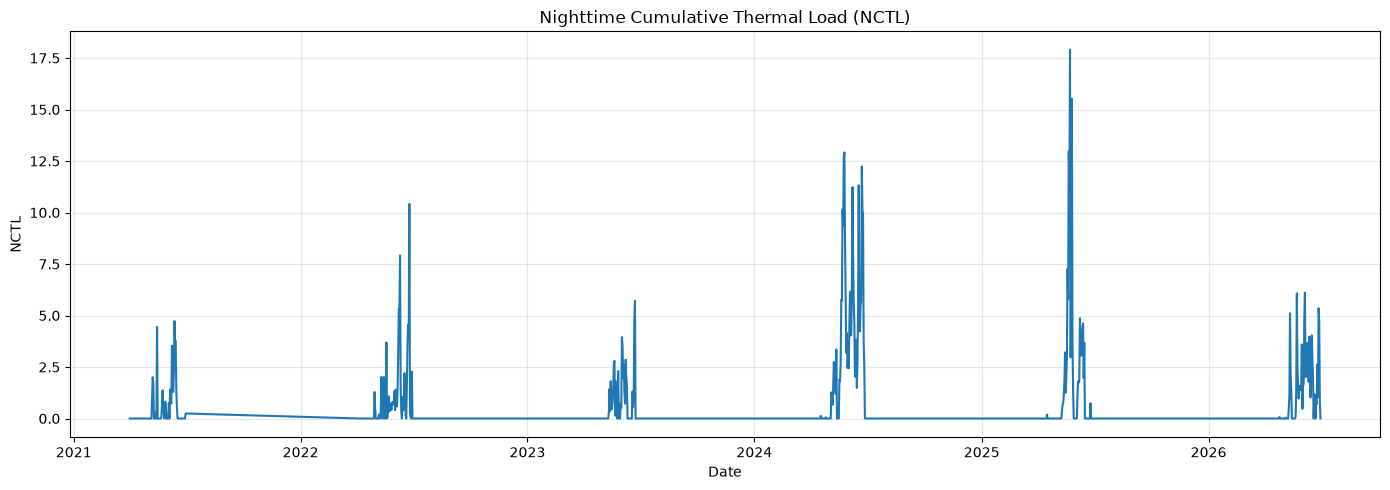

In [12]:
# GRAPH 2 — NCTL

plt.figure(figsize=(14, 5))

plt.plot(
    nctl_df["date"],
    nctl_df["NCTL"]
)

plt.xlabel("Date")
plt.ylabel("NCTL")
plt.title("Nighttime Cumulative Thermal Load (NCTL)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
day_stress = pd.read_csv(
    r"..\data\processed\daystress.csv"
)

day_stress["date"] = pd.to_datetime(day_stress["date"])

nctl_df = nctl_df.copy()

nctl_df["date"] = pd.to_datetime(nctl_df["date"])

nctl_df = nctl_df[
    ["date", "year", "NCTL"]
].copy()


In [14]:
ctbi_df = day_stress.merge(
    nctl_df,
    on="date",
    how="inner"
)

ctbi_df["year"] = ctbi_df["date"].dt.year

ctbi_df = (
    ctbi_df
    .sort_values(["year", "date"])
    .reset_index(drop=True)
)

ctbi_df.head(10)


,date,DayStress,year,NCTL
0,2021-04-01,37.309403,2021,0.0
1,2021-04-02,38.303439,2021,0.0
2,2021-04-03,38.912634,2021,0.0
3,2021-04-04,39.233238,2021,0.0
4,2021-04-05,39.910378,2021,0.0
5,2021-04-06,39.380991,2021,0.0
6,2021-04-07,38.458063,2021,0.0
7,2021-04-08,38.918738,2021,0.0
8,2021-04-09,38.351924,2021,0.0
9,2021-04-10,38.701540,2021,0.0


In [15]:
def minmax_normalize(series):
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            0.0,
            index=series.index
        )

    return (
        (series - minimum)
        / (maximum - minimum)
    )


ctbi_df["DayStress_norm"] = minmax_normalize(
    ctbi_df["DayStress"]
)

ctbi_df["NCTL_norm"] = minmax_normalize(
    ctbi_df["NCTL"]
)

print(
    ctbi_df[
        [
            "date",
            "DayStress",
            "DayStress_norm",
            "NCTL",
            "NCTL_norm"
        ]
    ].head(20)
)

         date  DayStress  DayStress_norm  NCTL  NCTL_norm
0  2021-04-01  37.309403        0.684861   0.0        0.0
1  2021-04-02  38.303439        0.726934   0.0        0.0
2  2021-04-03  38.912634        0.752718   0.0        0.0
3  2021-04-04  39.233238        0.766288   0.0        0.0
4  2021-04-05  39.910378        0.794948   0.0        0.0
5  2021-04-06  39.380991        0.772542   0.0        0.0
6  2021-04-07  38.458063        0.733478   0.0        0.0
7  2021-04-08  38.918738        0.752976   0.0        0.0
8  2021-04-09  38.351924        0.728986   0.0        0.0
9  2021-04-10  38.701540        0.743783   0.0        0.0
10 2021-04-11  39.419023        0.774151   0.0        0.0
11 2021-04-12  39.683080        0.785328   0.0        0.0
12 2021-04-13  38.309236        0.727179   0.0        0.0
13 2021-04-14  37.545121        0.694838   0.0        0.0
14 2021-04-15  38.841323        0.749700   0.0        0.0
15 2021-04-16  38.603959        0.739653   0.0        0.0
16 2021-04-17 

In [16]:
# ---------------------------------------------------------
# CTBI + ALPHA SENSITIVITY TEST
# ---------------------------------------------------------

BETA = 0.15
GAMMA = 0.15

ALPHAS = [0.60, 0.70, 0.80]

alpha_results = []

for alpha in ALPHAS:

    ctbi_values = []

    # Reset CTBI memory at the start of each year
    for year, yearly_data in ctbi_df.groupby("year", sort=True):

        yearly_data = (
            yearly_data
            .sort_values("date")
            .copy()
        )

        previous_ctbi = 0.0

        for _, row in yearly_data.iterrows():

            current_ctbi = (
                alpha * previous_ctbi
                + BETA * row["DayStress_norm"]
                + GAMMA * row["NCTL_norm"]
            )

            ctbi_values.append(
                (row["date"], current_ctbi)
            )

            previous_ctbi = current_ctbi

    alpha_df = pd.DataFrame(
        ctbi_values,
        columns=["date", f"CTBI_alpha_{alpha:.2f}"]
    )

    alpha_results.append(alpha_df)


# Merge all Alpha results together
ctbi_alpha_df = alpha_results[0]

for alpha_df in alpha_results[1:]:
    ctbi_alpha_df = ctbi_alpha_df.merge(
        alpha_df,
        on="date",
        how="left"
    )


# Keep Alpha = 0.70 as the main CTBI used elsewhere
ctbi_df = ctbi_df.drop(
    columns=["CTBI"],
    errors="ignore"
)

ctbi_df = ctbi_df.merge(
    ctbi_alpha_df[["date", "CTBI_alpha_0.70"]],
    on="date",
    how="left"
)

ctbi_df = ctbi_df.rename(
    columns={
        "CTBI_alpha_0.70": "CTBI"
    }
)


print("Alpha sensitivity results:")
print(
    ctbi_alpha_df.head(20)
)

Alpha sensitivity results:
         date  CTBI_alpha_0.60  CTBI_alpha_0.70  CTBI_alpha_0.80
0  2021-04-01         0.102729         0.102729         0.102729
1  2021-04-02         0.170678         0.180950         0.191223
2  2021-04-03         0.215314         0.239573         0.265886
3  2021-04-04         0.244132         0.282644         0.327652
4  2021-04-05         0.265721         0.317093         0.381364
5  2021-04-06         0.275314         0.337846         0.420972
6  2021-04-07         0.275210         0.346514         0.446800
7  2021-04-08         0.278073         0.355506         0.470386
8  2021-04-09         0.276191         0.358202         0.485657
9  2021-04-10         0.277282         0.362309         0.500093
10 2021-04-11         0.282492         0.369739         0.516197
11 2021-04-12         0.287294         0.376617         0.530757
12 2021-04-13         0.281453         0.372708         0.533682
13 2021-04-14         0.273098         0.365122         0.53117

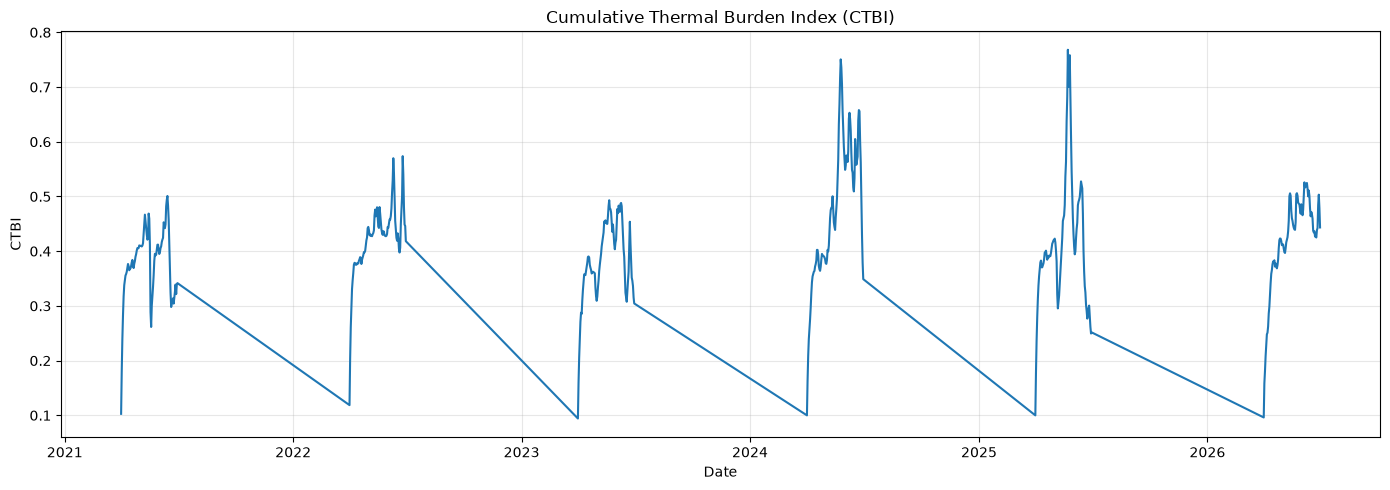

In [17]:
# GRAPH 3 — CTBI

plt.figure(figsize=(14, 5))

plt.plot(
    ctbi_df["date"],
    ctbi_df["CTBI"]
)

plt.xlabel("Date")
plt.ylabel("CTBI")
plt.title("Cumulative Thermal Burden Index (CTBI)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
from pathlib import Path

output_path = Path("../data/processed/CTBI.csv")

ctbi_df.to_csv(
    output_path,
    index=False
)

print(f"Saved: {output_path}")
print(f"Rows: {len(ctbi_df):,}")
print(f"Columns: {ctbi_df.columns.tolist()}")

Saved: ..\data\processed\CTBI.csv
Rows: 546
Columns: ['date', 'DayStress', 'year', 'NCTL', 'DayStress_norm', 'NCTL_norm', 'CTBI']
